In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests



plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")


# - dirs 
from ciim.src.common import mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types

from ciim.src.tf_activity.helper import retrieve_feature_data, retrieve_adata, retrieve_net, calculate_tf_activity
from ciim.src.tf_activity.helper import retrieve_sig_stats
from ciim.src.tf_activity.plots import  plot_net_nx

from ciim.src.utils.plots import dotplot

# Cell report 2021

In [27]:
features=['FOXO1', 'TCF7', 'BACH2', 'JUNB', 'FOS', 'FOSB']
type = 'bulk'
cell_type='CD8T'

# FOXO1 target regulation (Tcf7, Ccr7, Sell).

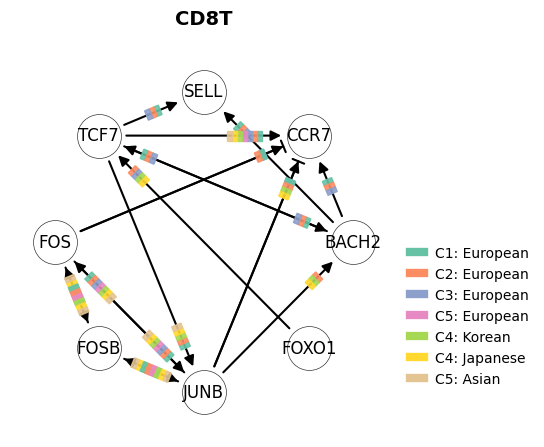

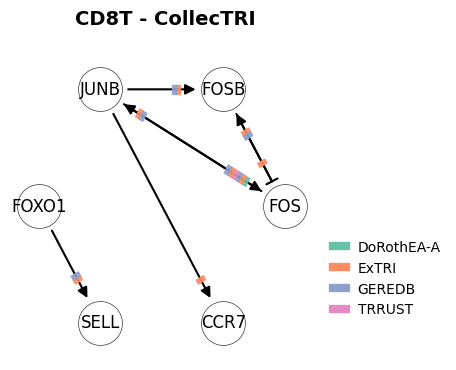

In [29]:
from ciim.src.tf_activity.plots import wrapper_draw_net

wrapper_draw_net(cell_type, datasets_all, features, min_degree=3, indivitual_net=False, draw_evidence=True, figsize=(5, 5), 
                figsize_collectri=(4, 4), 
                offset_evidence=.1, offset_evidence_collectri=.11,arc_offset=.05)

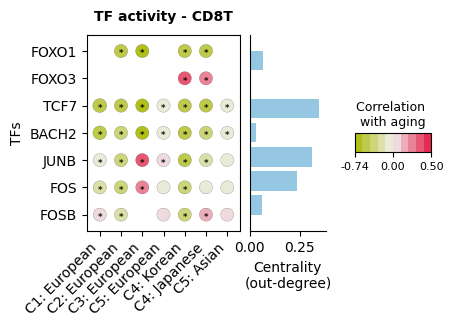

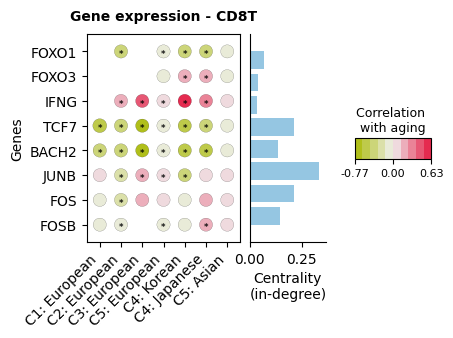

In [9]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets
plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, feature_type='tf_activity', sizes=(90, 100), width=4, margins={'x': 0.1, 'y': 0.1})
plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, feature_type='gene_expression', sizes=(90, 100), width=4, margins={'x': 0.1, 'y': 0.1})

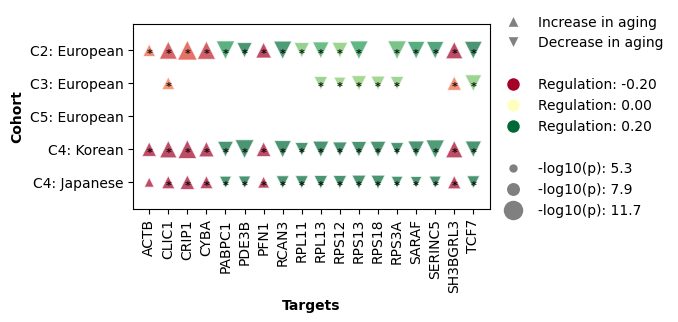

In [10]:
from ciim.src.tf_activity.plots import wrapper_flesh_out_tf_interactions
tf_case = 'FOXO1'
n_top_genes_per_dataset=10
wrapper_flesh_out_tf_interactions(datasets_all, cell_type, tf=tf_case, type=type, n_top=n_top_genes_per_dataset, keep_sig_only=False, sizes=(50, 200))


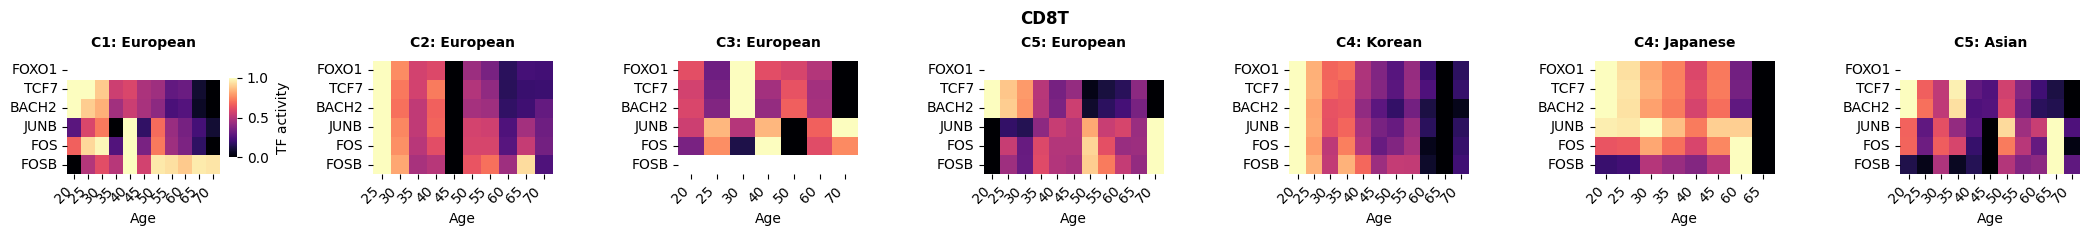

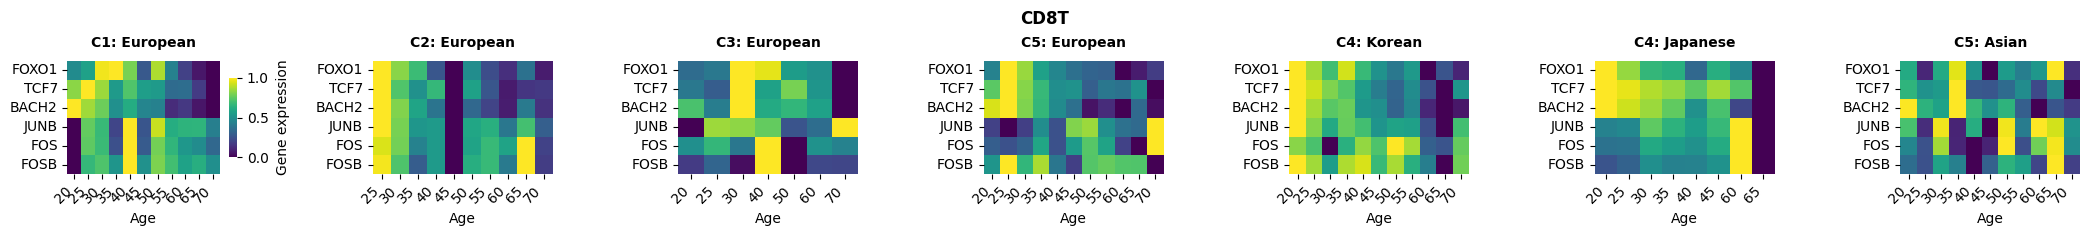

In [44]:
from ciim.src.tf_activity.plots import plot_feature_values_per_datasets

plot_feature_values_per_datasets(cell_type, features, type, datasets_all, feature_type='tf_activity', age_limit=[20, 75], cluster=False)
plot_feature_values_per_datasets(cell_type, features, type, datasets_all, feature_type='gene_expression', age_limit=[20, 75], cluster=False)

# Goto 2024

In [33]:
type = 'bulk'
cell_type = 'CD8T' #'Tcm_Naive_CD8'
n_top=10
features = ['ZEB2', 'TBX21', 'GZMA', 'CXCL13']

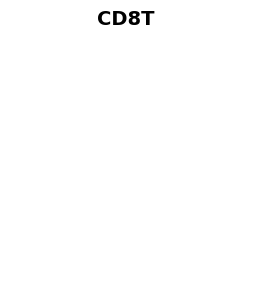

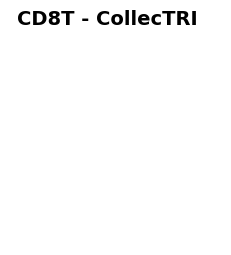

In [34]:
from ciim.src.tf_activity.plots import wrapper_draw_net

wrapper_draw_net(cell_type, datasets_all, features, min_degree=1, indivitual_net=False, draw_evidence=True, figsize=(3, 3), figsize_collectri=(2.5, 2.5), 
                 offset_evidence=.13, arc_offset=.05)

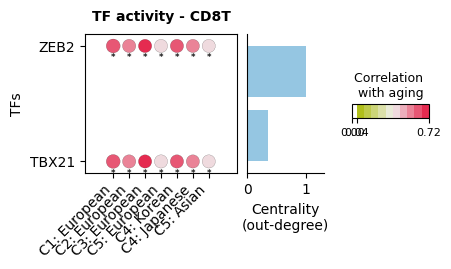

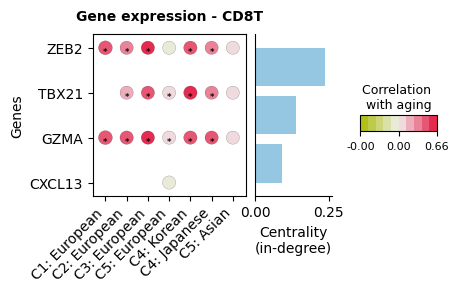

In [36]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets

plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, feature_type='tf_activity', sizes=(90, 100), width=4, margins={'x': 0.3, 'y': 0.1})
plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, feature_type='gene_expression', sizes=(90, 100), width=4, margins={'x': 0.1, 'y': .1})

# Moskowitz 2017

In [8]:
type = 'bulk'
cell_type = 'CD8T' #'Tcm_Naive_CD8'
n_top=10
features = ['BACH2', 'PRDM1', 'BATF', 'ETS1', 'SP1', 'EOMES', 'NRF1']

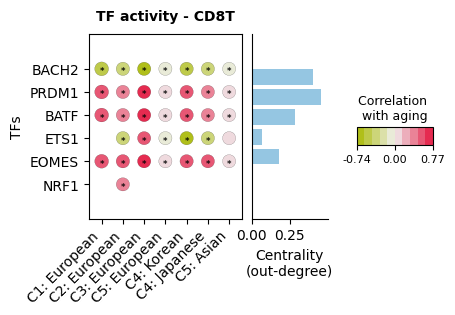

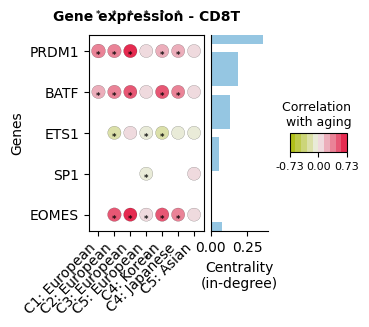

In [9]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets

plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, feature_type='tf_activity', sizes=(90, 100), width=4, margins={'x': 0.1, 'y': 0.3})
plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, feature_type='gene_expression', sizes=(90, 100), width=3, margins={'x': 0.1, 'y': -.1})

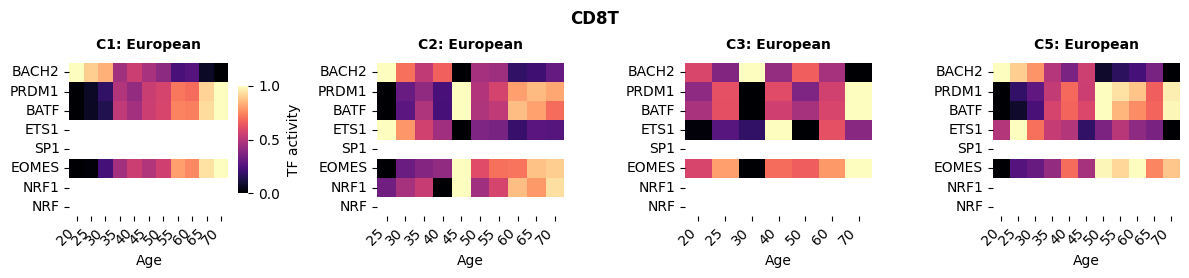

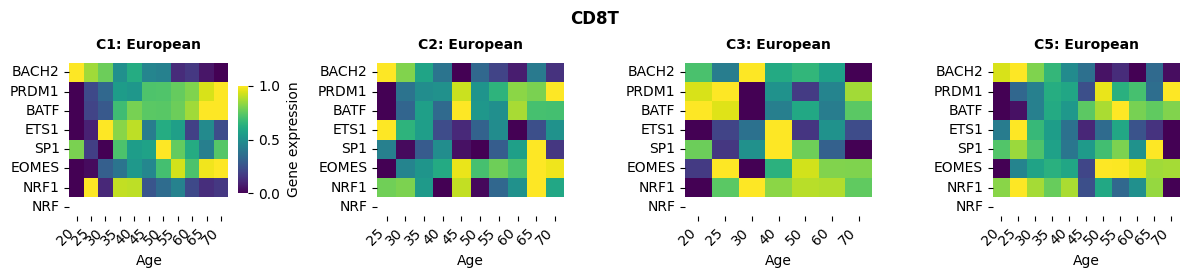

In [10]:
from ciim.src.tf_activity.plots import plot_feature_values_per_datasets
plot_feature_values_per_datasets(cell_type, features, type, datasets_e, feature_type='tf_activity', age_limit=[20, 75], cluster=False)
plot_feature_values_per_datasets(cell_type, features, type, datasets_e, feature_type='gene_expression', age_limit=[20, 75], cluster=False)

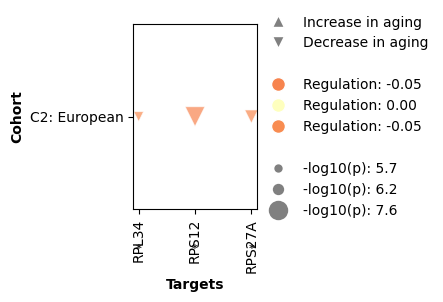

In [232]:
from ciim.src.tf_activity.plots import wrapper_flesh_out_tf_interactions
tf_case = 'NRF1'
n_top_genes_per_dataset=10
wrapper_flesh_out_tf_interactions(datasets_all, cell_type, tf=tf_case, type=type, n_top=n_top_genes_per_dataset, keep_sig_only=False, sizes=(50, 200))

# Turano 2025

In [29]:
type = 'bulk'
cell_type = 'CD8T' #'Tcm_Naive_CD8'
n_top=10
tfs_1 = ['MYC'] # enriched in non-senescence cells
tfs_2 = ['TBX21'] # nearby enhancers switched on in senescence
genes = ['TBKBP1', 'LAYN'] # nearby enhancers switched on in senescence

tfs_3 = ['FOSL2', 'FOS', 'MAF', 'MAFB', 'BACH1', 'BACH2', 'TBX1', 'EOMES'] # their binding increased in senescence
tfs_4 = ['E2F6', 'RGR2', 'MYC'] # their binding decreased in senescence

features = tfs_1+tfs_2+genes+tfs_3+tfs_4 
features = np.unique(features)


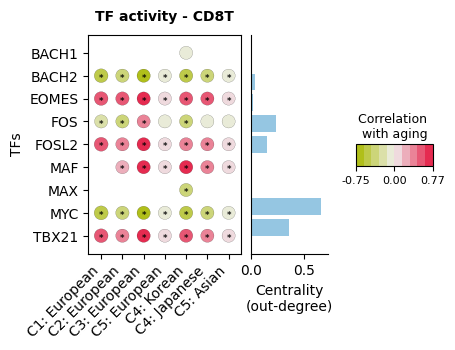

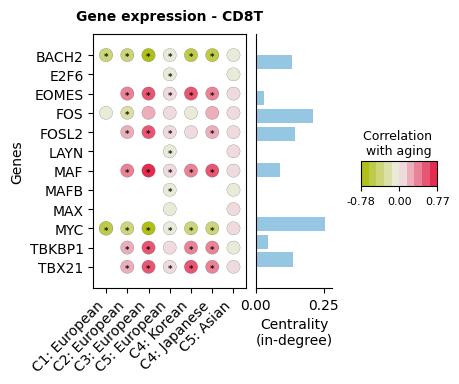

In [32]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets

plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, feature_type='tf_activity', sizes=(90, 100), width=4, margins={'x': 0.1, 'y': 0.1})
plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, feature_type='gene_expression', sizes=(90, 100), width=4, margins={'x': 0.1, 'y': .1})

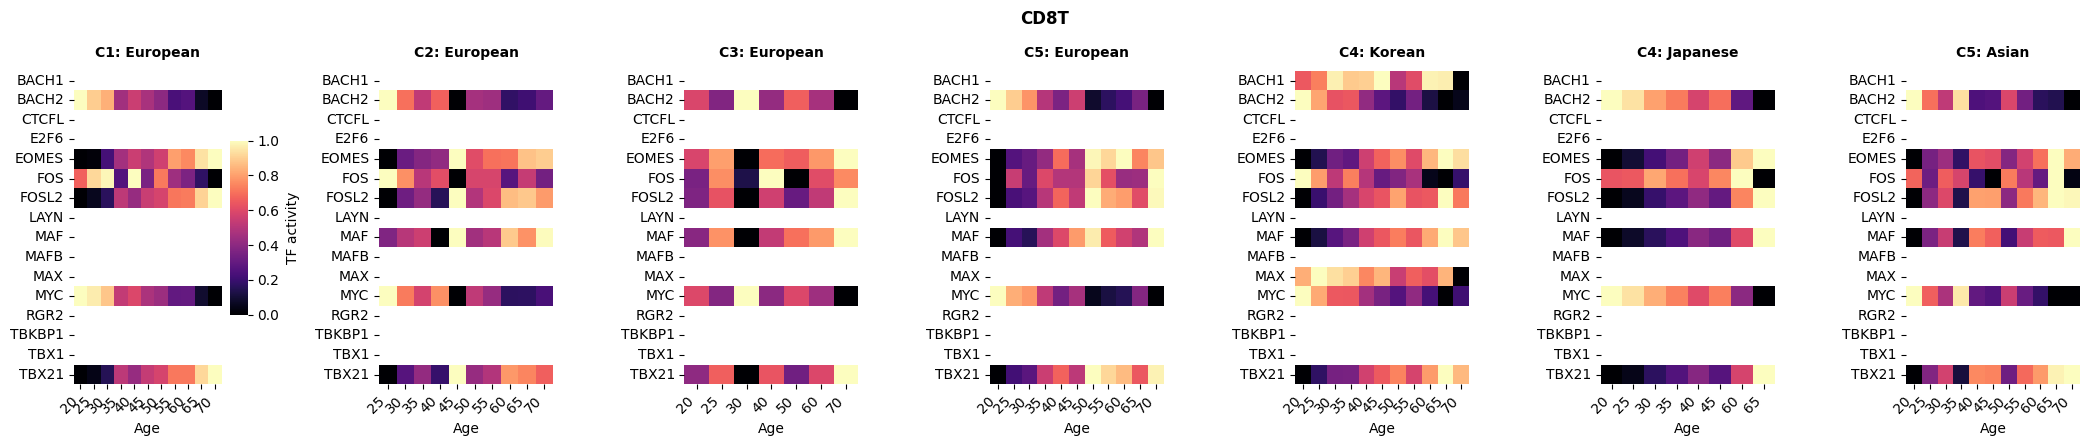

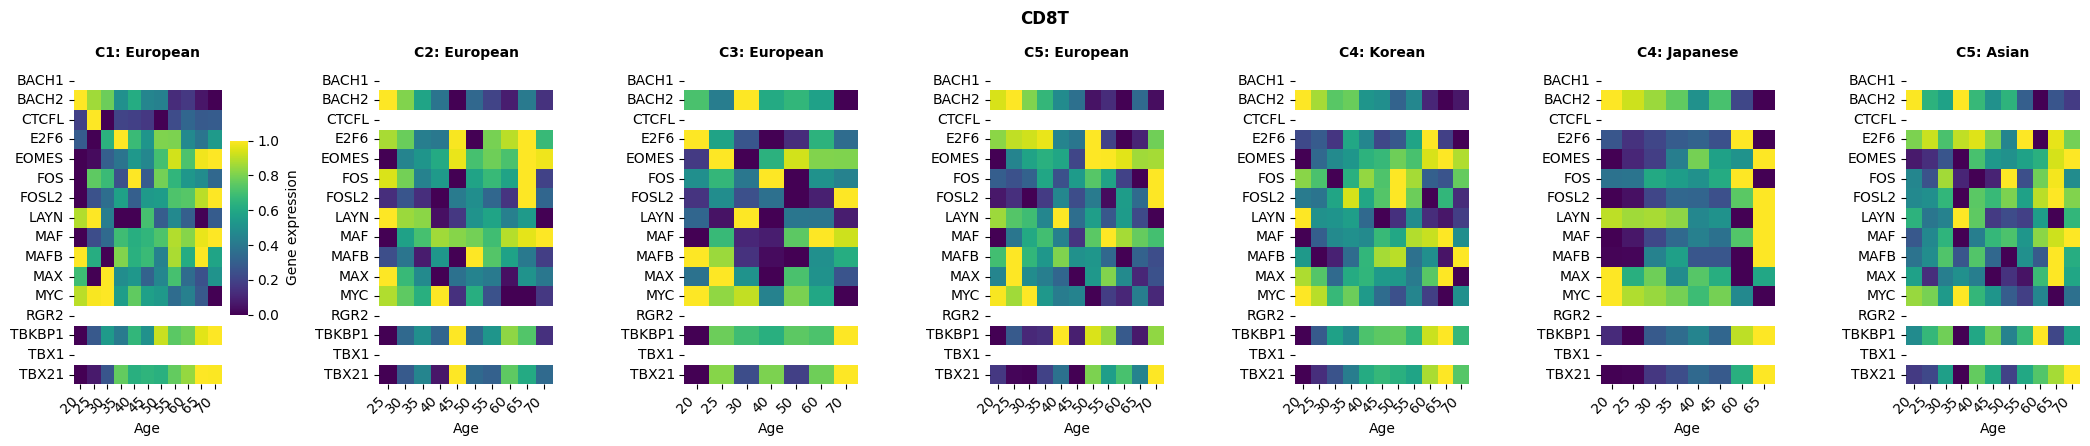

In [31]:
from ciim.src.tf_activity.plots import plot_feature_values_per_datasets
plot_feature_values_per_datasets(cell_type, features, type, datasets_all, feature_type='tf_activity', age_limit=[20, 75], cluster=False)
plot_feature_values_per_datasets(cell_type, features, type, datasets_all, feature_type='gene_expression', age_limit=[20, 75], cluster=False)

# Test

In [30]:
type = 'bulk'
cell_type = 'MONO' #'Tcm_Naive_CD8'
n_top=10
features = ['FOXO1', 'FOXO3', 'NFE2L2', 'TP53', 'SIRT1', 'HIF1A']

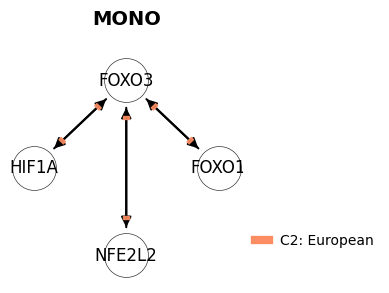

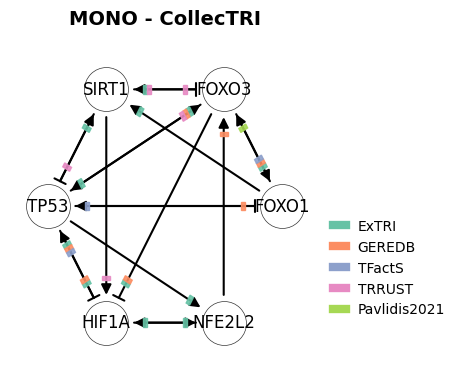

In [31]:
from ciim.src.tf_activity.plots import wrapper_draw_net

wrapper_draw_net(cell_type, datasets_all, features, min_degree=1, indivitual_net=False, draw_evidence=True, figsize=(3, 3), figsize_collectri=(4, 4), 
                 offset_evidence=.13, arc_offset=.05)

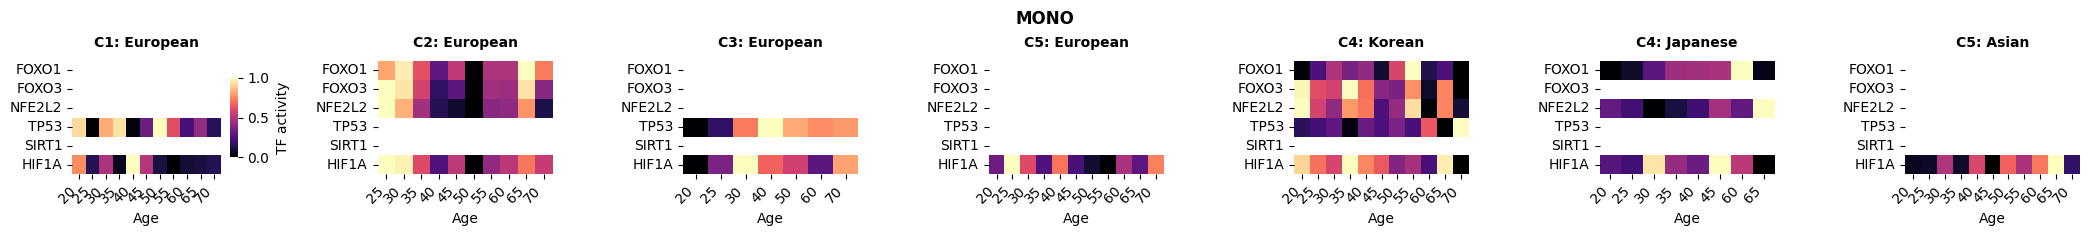

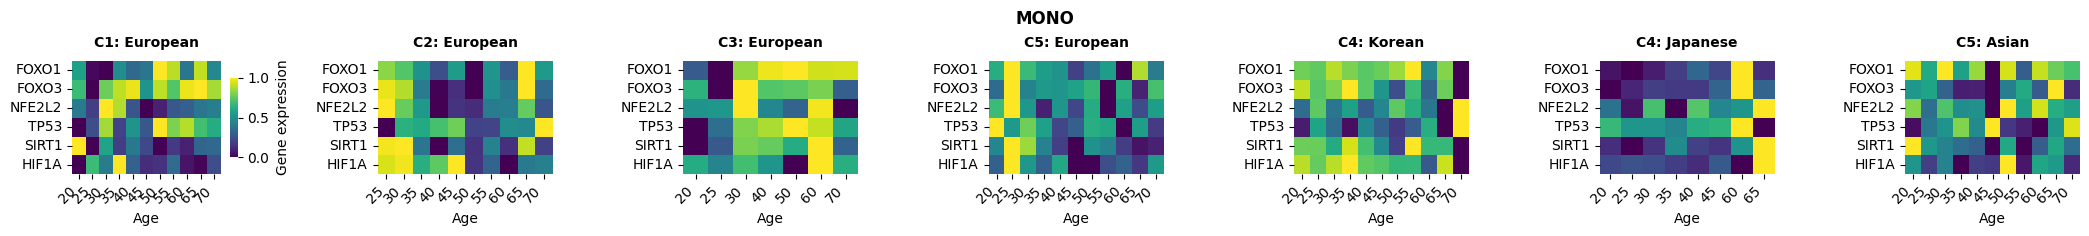

In [19]:
from ciim.src.tf_activity.plots import plot_feature_values_per_datasets
plot_feature_values_per_datasets(cell_type, features, type, datasets_all, feature_type='tf_activity', age_limit=[20, 75], cluster=False)
plot_feature_values_per_datasets(cell_type, features, type, datasets_all, feature_type='gene_expression', age_limit=[20, 75], cluster=False)

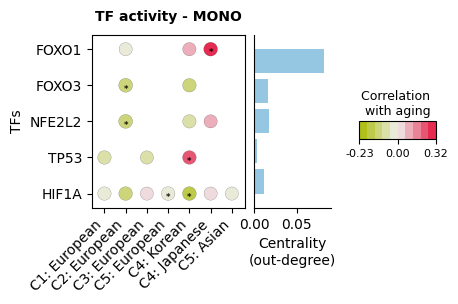

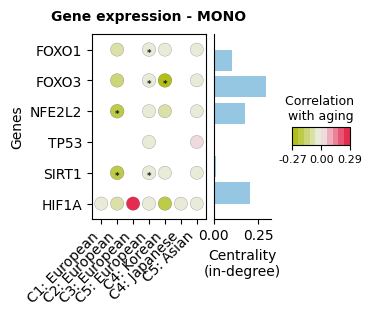

In [20]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets

plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, feature_type='tf_activity', sizes=(90, 100), width=4, margins={'x': 0.1, 'y': 0.1})
plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, feature_type='gene_expression', sizes=(90, 100), width=3, margins={'x': 0.1, 'y': .1})